# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

In [ ]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.stattools import adfuller

In [ ]:
df = pd.read_csv("exchange_rate.csv")

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [ ]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [ ]:
df.shape

(7588, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


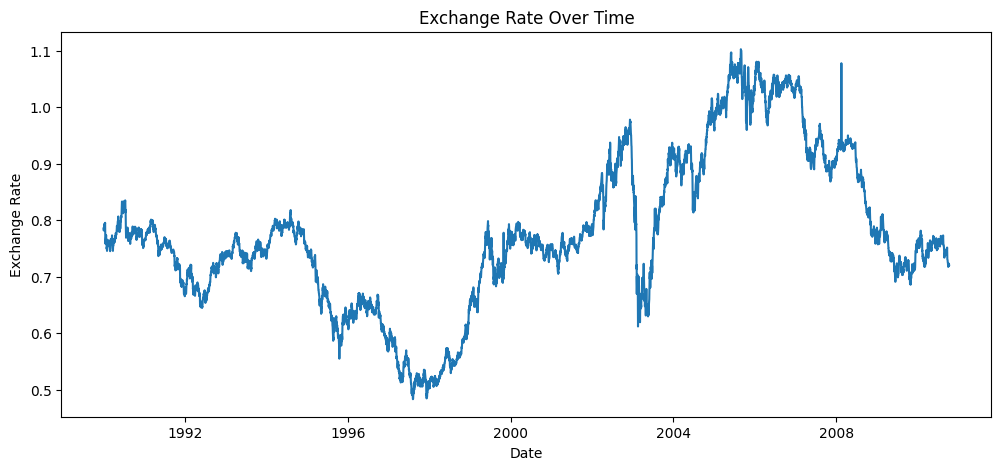

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['Ex_rate'])

plt.title("Exchange Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Exchange Rate")

plt.show()

In [ ]:
df.isnull().sum()

,0
Ex_rate,0


In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1055/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Model Building – ARIMA**

In [ ]:
#Train Test Split
train = df.iloc[:-30]

test = df.iloc[-30:]

In [ ]:
#Stationarity Test
result = adfuller(train['Ex_rate'])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -1.6765058667526576
p-value: 0.44325619290852813


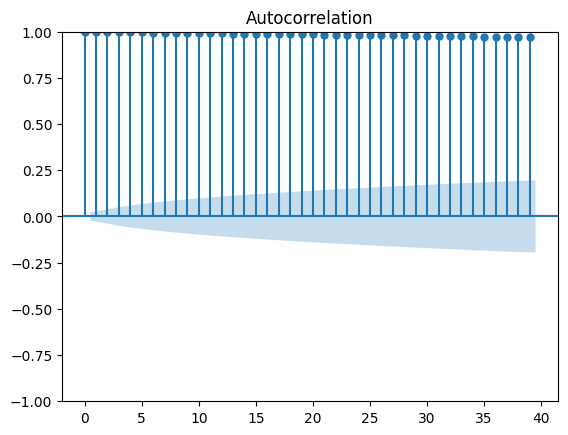

In [ ]:
#ACF Plot
plot_acf(train['Ex_rate'])

plt.show()

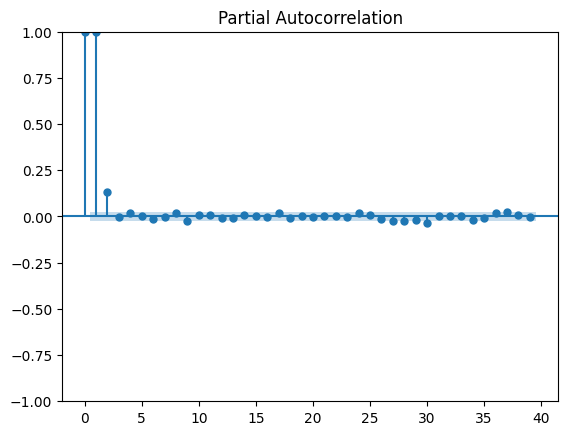

In [ ]:
#PACF Plot
plot_pacf(train['Ex_rate'])

plt.show()

In [ ]:
#Build ARIMA Model
model = ARIMA(train['Ex_rate'], order=(1,1,1))

arima_model = model.fit()

print(arima_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Thu, 25 Jun 2026   AIC                         -55862.942
Time:                        16:17:25   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.760      0.0

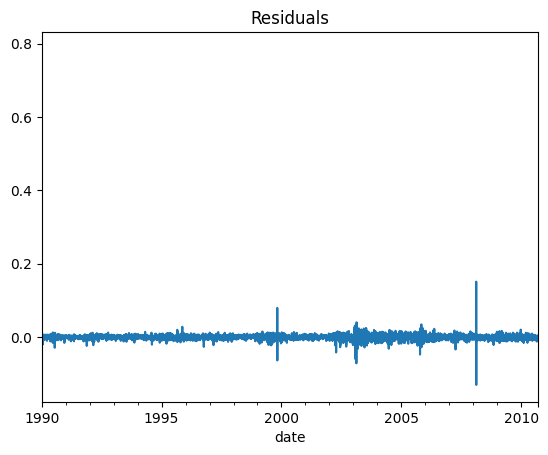

In [ ]:
#Diagnostics
arima_model.resid.plot()

plt.title("Residuals")

plt.show()

In [ ]:
#Forecast
forecast = arima_model.forecast(steps=30)

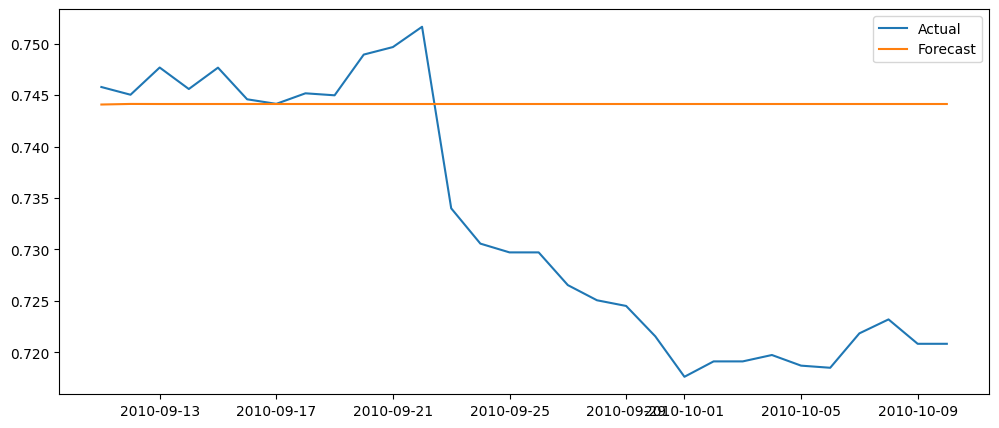

In [ ]:
#Forecast Visualization
plt.figure(figsize=(12,5))

plt.plot(test.index, test['Ex_rate'], label="Actual")

plt.plot(test.index, forecast, label="Forecast")

plt.legend()

plt.show()

**Exponential Smoothing**

In [ ]:
#Build Model
exp_model = ExponentialSmoothing(
    train['Ex_rate'],
    trend='add',
    seasonal=None
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
#Forecast
exp_forecast = exp_model.forecast(30)

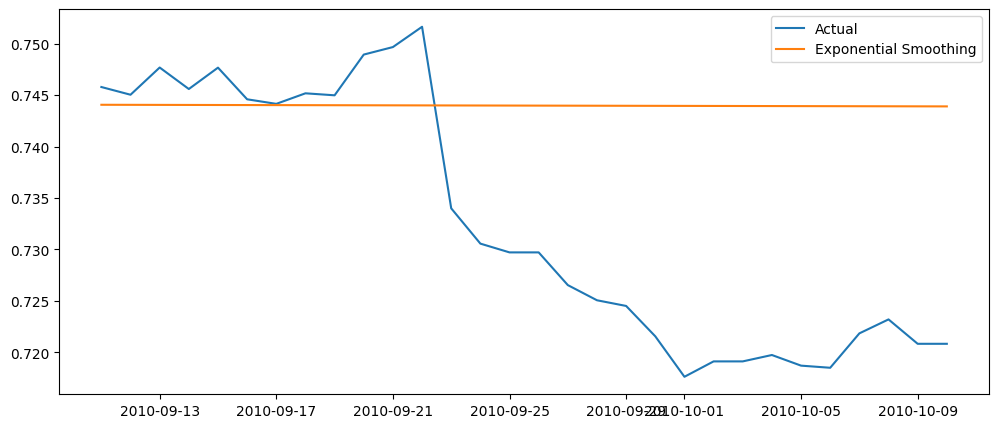

In [ ]:
#Visualization
plt.figure(figsize=(12,5))

plt.plot(test.index, test['Ex_rate'], label="Actual")

plt.plot(test.index, exp_forecast, label="Exponential Smoothing")

plt.legend()

plt.show()

**Evaluation and Comparison**

In [ ]:
#MAE
print("ARIMA MAE:",
      mean_absolute_error(
          test['Ex_rate'],
          forecast
      ))

print("EXP MAE:",
      mean_absolute_error(
          test['Ex_rate'],
          exp_forecast
      ))

ARIMA MAE: 0.013494600805886207
EXP MAE: 0.013423166055128262


In [ ]:
#RMSE
print("ARIMA RMSE:",
      np.sqrt(
          mean_squared_error(
              test['Ex_rate'],
              forecast
          )
      ))

print("EXP RMSE:",
      np.sqrt(
          mean_squared_error(
              test['Ex_rate'],
              exp_forecast
          )
      ))

ARIMA RMSE: 0.016632177913116195
EXP RMSE: 0.01649594233495601


In [ ]:
#MAPE
def mape(actual,pred):

    return np.mean(
        np.abs(
            (actual-pred)/actual
        )
    )*100

In [ ]:
print("ARIMA MAPE:",
      mape(
          test['Ex_rate'],
          forecast
      ))

print("EXP MAPE:",
      mape(
          test['Ex_rate'],
          exp_forecast
      ))

ARIMA MAPE: 1.8632207485601178
EXP MAPE: 1.8531561193841917


In [ ]:
#Comparison Table
comparison = pd.DataFrame({

    "Model":[
        "ARIMA",
        "Exponential Smoothing"
    ],

    "MAE":[
        mean_absolute_error(
            test['Ex_rate'],
            forecast
        ),

        mean_absolute_error(
            test['Ex_rate'],
            exp_forecast
        )
    ],

    "RMSE":[
        np.sqrt(
            mean_squared_error(
                test['Ex_rate'],
                forecast
            )
        ),

        np.sqrt(
            mean_squared_error(
                test['Ex_rate'],
                exp_forecast
            )
        )
    ],

    "MAPE":[
        mape(
            test['Ex_rate'],
            forecast
        ),

        mape(
            test['Ex_rate'],
            exp_forecast
        )
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,0.013495,0.016632,1.863221
1,Exponential Smoothing,0.013423,0.016496,1.853156


Model Comparison :

Compare the MAE, RMSE, and MAPE values of both models. The model with lower error values provides more accurate forecasts. ARIMA is generally effective for stationary time-series data, while Exponential Smoothing performs well when recent observations are more relevant for forecasting.

Conclusion

This analysis compared ARIMA and Exponential Smoothing for forecasting exchange rates. Both models were evaluated using MAE, RMSE, and MAPE. The model with the lower error metrics is considered more suitable for forecasting this exchange rate dataset. These forecasting techniques can help financial analysts and businesses make better decisions related to currency exchange trends.